In [1]:
import numpy as np
import pandas as pd
import os
import torch
import random
import pickle
from tqdm import tqdm
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

100%|██████████| 41.0M/41.0M [00:00<00:00, 80.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1


In [3]:
path = "/root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1"
csv_file1 = os.path.join(path, "Fake.csv")
csv_file2 = os.path.join(path, "True.csv")
df_fake= pd.read_csv(csv_file1)
df_true = pd.read_csv(csv_file2)
# Add 'label'
df_fake['label'] = 'fake'
df_true['label'] = 'true'

# Combine the datasets
df = pd.concat([df_fake, df_true], ignore_index=True)

# Merge 'Title' and 'Text' into a single 'Text' column
df['text'] = df['title'] + df['text']

# Drop the original 'Title' column
df.drop(columns=['title'], inplace=True)

texts = df['text'].tolist()
labels = df['label'].tolist()

# Text cleaning
import re
def clean(text):
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    return text

cleaned = [clean(text) for text in texts]

# Split the dataset 0.8 train, 0.2 test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(cleaned, labels, test_size=0.2, random_state=42, shuffle=True, stratify=labels)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 35918
Test set size: 8980


In [4]:
# Tokenization for data
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [5]:
# Padding for data
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 1000  # Maximum length of sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [6]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

label_encoder = LabelEncoder()
y_train_ = label_encoder.fit_transform(y_train)
y_test_ = label_encoder.transform(y_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_, dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [12]:
from tqdm import tqdm
import torch.optim as optim

def train_model(model, train_loader, num_epochs, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        with tqdm(train_loader, unit="batch") as tepoch:
            tepoch.set_description(f"Epoch {epoch + 1}/{num_epochs}")

            for X_batch, y_batch in tepoch:
                # Initialize the hidden state
                hidden = model.init_hidden(X_batch.size(0))

                # Forward pass
                outputs, hidden = model(X_batch, hidden)
                loss = criterion(outputs, y_batch)

                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Calculate accuracy
                _, preds = torch.max(outputs, 1)
                batch_accuracy = (preds == y_batch).float().mean().item()
                # Update metrics
                epoch_loss += loss.item()
                epoch_accuracy += batch_accuracy

                # Update TQDM progress bar
                tepoch.set_postfix(loss=loss.item(), accuracy=batch_accuracy)

        # Average loss and accuracy for the epoch
        epoch_loss /= len(train_loader)
        epoch_accuracy /= len(train_loader)
        print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()  # Loss function for evaluation
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to calculate gradients during evaluation
        with tqdm(test_loader, unit="batch") as tepoch:
            tepoch.set_description("Evaluating")

            for X_batch, y_batch in tepoch:
                # Initialize the hidden state
                hidden = model.init_hidden(X_batch.size(0))

                # Forward pass
                outputs, hidden = model(X_batch, hidden)
                loss = criterion(outputs, y_batch)  # Compute loss

                # Track predictions and labels
                _, preds = torch.max(outputs, 1)  # Predicted class indices
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

                # Update metrics
                total_loss += loss.item()
                batch_accuracy = (preds == y_batch).float().mean().item()
                tepoch.set_postfix(loss=loss.item(), accuracy=batch_accuracy)

    # Calculate average loss
    avg_loss = total_loss / len(test_loader)

    # Compute additional metrics
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    accuracy = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()

    print(f"Evaluation - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    confusion = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


    return avg_loss, {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": confusion
    }

In [13]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(RNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden):
        embeds = self.embedding(x)
        out, hidden = self.rnn(embeds, hidden)
        last_hidden = out[:, -1, :]
        logits = self.fc(last_hidden)
        return logits, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_dim)

In [24]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden):
        embeds = self.embedding(x)  # Shape: (batch_size, seq_length, embedding_dim)
        out, hidden = self.lstm(embeds, hidden)
        last_hidden = out[:, -1, :]  # Use the last output vector
        logits = self.fc(last_hidden)  # Shape: (batch_size, output_dim)
        return logits, hidden  # Return raw logits

    def init_hidden(self, batch_size):
        # Initialize hidden state and cell state to zeros
        hidden_state = torch.zeros(1, batch_size, self.hidden_dim)
        cell_state = torch.zeros(1, batch_size, self.hidden_dim)
        return (hidden_state, cell_state)


In [ ]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64
hidden_dim = 64
output_dim = 2
num_epochs = 5


RNNmodel = RNN(vocab_size, embedding_dim, hidden_dim, output_dim)
# Train the model
train_model(RNNmodel, train_loader, num_epochs)
# Save the trained model
torch.save(RNNmodel.state_dict(), "RNNmodel1.pth")
print("Model saved as 'RNNmodel1.pth'")
torch.save(RNNmodel.state_dict(), "/content/drive/My Drive/RNNmodel1.pth")
print("Model saved to Google Drive.")

Epoch 1/5: 100%|██████████| 562/562 [03:24<00:00,  2.75batch/s, accuracy=1, loss=0.0642]


Epoch 1/5 - Loss: 0.3512, Accuracy: 0.8415


Epoch 2/5: 100%|██████████| 562/562 [03:15<00:00,  2.87batch/s, accuracy=0.857, loss=0.396]


Epoch 2/5 - Loss: 0.2458, Accuracy: 0.9047


Epoch 3/5: 100%|██████████| 562/562 [03:10<00:00,  2.94batch/s, accuracy=1, loss=0.104]


Epoch 3/5 - Loss: 0.2614, Accuracy: 0.8947


Epoch 4/5: 100%|██████████| 562/562 [03:05<00:00,  3.03batch/s, accuracy=0.786, loss=0.632]


Epoch 4/5 - Loss: 0.1559, Accuracy: 0.9447


Epoch 5/5: 100%|██████████| 562/562 [02:49<00:00,  3.31batch/s, accuracy=0.929, loss=0.158]

Epoch 5/5 - Loss: 0.3072, Accuracy: 0.8632
Model saved as 'RNNmodel1.pth'
Model saved to Google Drive.


Epoch 1/5: 100%|██████████| 562/562 [03:24<00:00,  2.75batch/s, accuracy=1, loss=0.0642]
Epoch 1/5 - Loss: 0.3512, Accuracy: 0.8415
Epoch 2/5: 100%|██████████| 562/562 [03:15<00:00,  2.87batch/s, accuracy=0.857, loss=0.396]
Epoch 2/5 - Loss: 0.2458, Accuracy: 0.9047
Epoch 3/5: 100%|██████████| 562/562 [03:10<00:00,  2.94batch/s, accuracy=1, loss=0.104]
Epoch 3/5 - Loss: 0.2614, Accuracy: 0.8947
Epoch 4/5: 100%|██████████| 562/562 [03:05<00:00,  3.03batch/s, accuracy=0.786, loss=0.632]
Epoch 4/5 - Loss: 0.1559, Accuracy: 0.9447
Epoch 5/5: 100%|██████████| 562/562 [02:49<00:00,  3.31batch/s, accuracy=0.929, loss=0.158]Epoch 5/5 - Loss: 0.3072, Accuracy: 0.8632
Model saved as 'RNNmodel1.pth'
Model saved to Google Drive.

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64
hidden_dim = 64
output_dim = 2
num_epochs = 5


LSTMmodel = LSTM(vocab_size, embedding_dim, hidden_dim, output_dim)
# Train the model
train_model(LSTMmodel, train_loader, num_epochs)
# Save the trained model
torch.save(LSTMmodel.state_dict(), "LSTMmodel1.pth")
print("Model saved as 'LSTMmodel1.pth'")
torch.save(LSTMmodel.state_dict(), "/content/drive/My Drive/LSTMmodel1.pth")
print("Model saved to Google Drive.")

Epoch 1/5: 100%|██████████| 562/562 [07:03<00:00,  1.33batch/s, accuracy=1, loss=0.0834]


Epoch 1/5 - Loss: 0.3094, Accuracy: 0.8644


Epoch 2/5: 100%|██████████| 562/562 [08:53<00:00,  1.05batch/s, accuracy=0.429, loss=0.754]


Epoch 2/5 - Loss: 0.1694, Accuracy: 0.9360


Epoch 3/5: 100%|██████████| 562/562 [07:57<00:00,  1.18batch/s, accuracy=1, loss=0.0118]


Epoch 3/5 - Loss: 0.1461, Accuracy: 0.9411


Epoch 4/5: 100%|██████████| 562/562 [09:34<00:00,  1.02s/batch, accuracy=1, loss=0.00732]


Epoch 4/5 - Loss: 0.0557, Accuracy: 0.9825


Epoch 5/5: 100%|██████████| 562/562 [10:44<00:00,  1.15s/batch, accuracy=1, loss=0.0309]

Epoch 5/5 - Loss: 0.0449, Accuracy: 0.9859
Model saved as 'LSTMmodel1.pth'
Model saved to Google Drive.


Epoch 1/5: 100%|██████████| 562/562 [07:03<00:00,  1.33batch/s, accuracy=1, loss=0.0834]
Epoch 1/5 - Loss: 0.3094, Accuracy: 0.8644
Epoch 2/5: 100%|██████████| 562/562 [08:53<00:00,  1.05batch/s, accuracy=0.429, loss=0.754]
Epoch 2/5 - Loss: 0.1694, Accuracy: 0.9360
Epoch 3/5: 100%|██████████| 562/562 [07:57<00:00,  1.18batch/s, accuracy=1, loss=0.0118]
Epoch 3/5 - Loss: 0.1461, Accuracy: 0.9411
Epoch 4/5: 100%|██████████| 562/562 [09:34<00:00,  1.02s/batch, accuracy=1, loss=0.00732]
Epoch 4/5 - Loss: 0.0557, Accuracy: 0.9825
Epoch 5/5: 100%|██████████| 562/562 [10:44<00:00,  1.15s/batch, accuracy=1, loss=0.0309]Epoch 5/5 - Loss: 0.0449, Accuracy: 0.9859
Model saved as 'LSTMmodel1.pth'
Model saved to Google Drive.


In [16]:
model_path = '/content/drive/My Drive/RNNmodel1.pth'

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64
hidden_dim = 64
output_dim = 2
num_epochs = 5

RNNmodel = RNN(vocab_size, embedding_dim, hidden_dim, output_dim)
state_dict = torch.load(model_path)

RNNmodel.load_state_dict(state_dict)


<ipython-input-16-471b98b2f3b9>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


<All keys matched successfully>

Evaluating: 100%|██████████| 141/141 [00:05<00:00, 26.24batch/s, accuracy=0.9, loss=0.248]
Evaluation - Loss: 0.0713, Accuracy: 0.9768, Precision: 0.9770, Recall: 0.9768, F1-score: 0.9768
(0.0712881773505492,
 {'accuracy': 0.9768373966217041,
  'precision': 0.9769700031308265,
  'recall': 0.976837416481069,
  'f1_score': 0.976844302827169})

Evaluating: 100%|██████████| 141/141 [00:07<00:00, 18.41batch/s, accuracy=0.9, loss=0.238]


Evaluation - Loss: 0.2851, Accuracy: 0.8734, Precision: 0.8736, Recall: 0.8734, F1-score: 0.8734


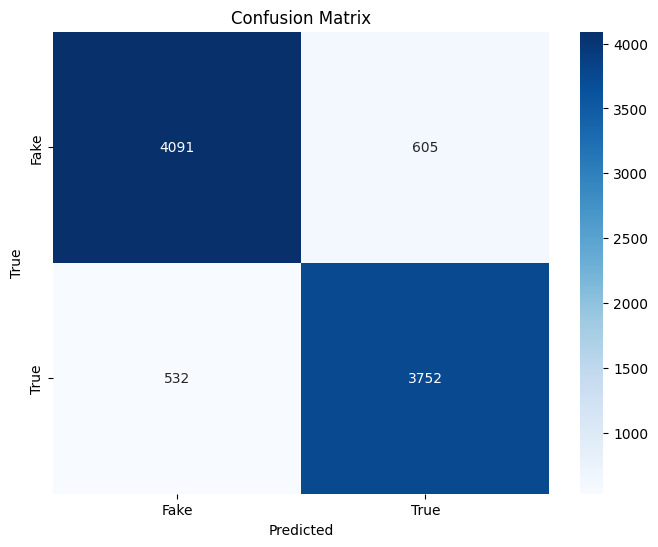

(0.28512182070853864,
 {'accuracy': 0.8733853101730347,
  'precision': 0.8735786142747407,
  'recall': 0.8733853006681515,
  'f1_score': 0.8734242117557136,
  'confusion_matrix': array([[4091,  605],
         [ 532, 3752]])})

In [22]:
evaluate_model(RNNmodel, test_loader)

In [25]:
model_path = '/content/drive/My Drive/LSTMmodel1.pth'

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64
hidden_dim = 64
output_dim = 2
num_epochs = 5

LSTMmodel = LSTM(vocab_size, embedding_dim, hidden_dim, output_dim)
state_dict = torch.load(model_path)
LSTMmodel.load_state_dict(state_dict)

<ipython-input-25-7d774e0498ac>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


<All keys matched successfully>

Evaluating: 100%|██████████| 141/141 [00:06<00:00, 21.30batch/s, accuracy=1, loss=0.00782]


Evaluation - Loss: 0.0701, Accuracy: 0.9768, Precision: 0.9770, Recall: 0.9768, F1-score: 0.9768


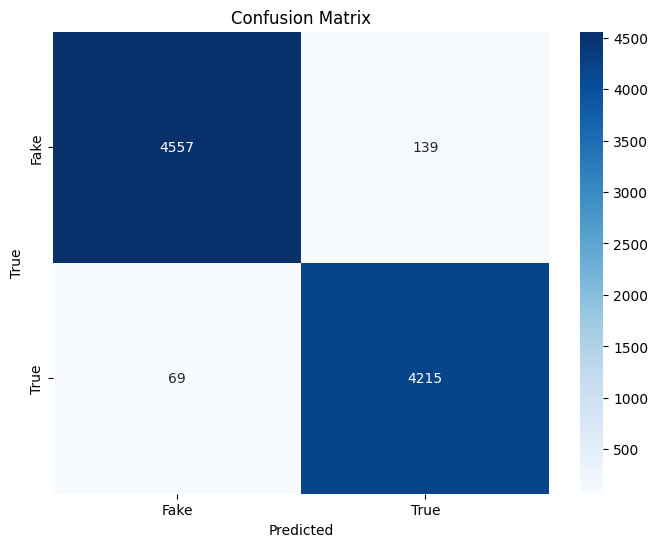

(0.07011656965465939,
 {'accuracy': 0.9768373966217041,
  'precision': 0.9769700031308265,
  'recall': 0.976837416481069,
  'f1_score': 0.976844302827169,
  'confusion_matrix': array([[4557,  139],
         [  69, 4215]])})

In [26]:
evaluate_model(LSTMmodel, test_loader)